In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
data = pl.read_csv("complete_aggregation3.csv")

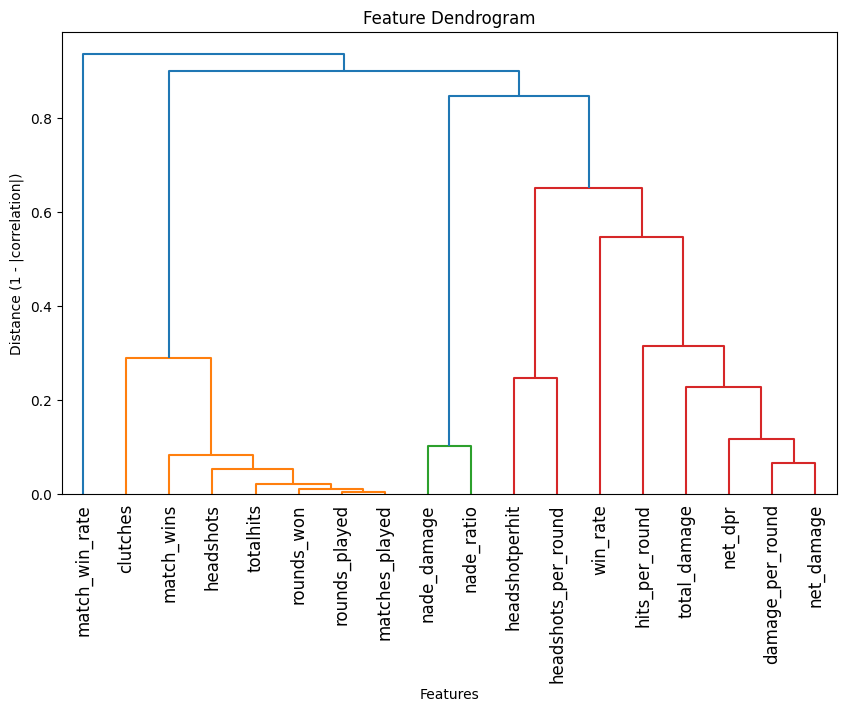

In [3]:
df = data.select(pl.all().exclude("player"))

corr = df.corr()
corr_np = corr.to_numpy()

dist = 1 - np.abs(corr_np)
dist_condensed = squareform(dist, checks=False)

Z = linkage(dist_condensed, method="average")

plt.figure(figsize=(10, 6))
dendrogram(Z, labels=df.columns)
plt.title("Feature Dendrogram")
plt.xlabel("Features")
plt.ylabel("Distance (1 - |correlation|)")
plt.xticks(rotation='vertical')
plt.show()

In [4]:
linkage_data = linkage(df, method='ward', metric='euclidean')
dendrogram(linkage_data)

plt.show() 


KeyboardInterrupt



KeyboardInterrupt: 

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# hierarchical clustering
linkage_data = linkage(df.to_numpy(), method='ward', metric='euclidean')

# plot dendrogram
plt.figure(figsize=(14, 8))

dendrogram(linkage_data)

plt.title("Hierarchical Clustering Dendrogram", fontsize=24)
plt.xlabel("Samples", fontsize=18)
plt.ylabel("Distance", fontsize=18)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.savefig("dendrogram.png", dpi=300, bbox_inches="tight")
plt.show()
plt.clf()

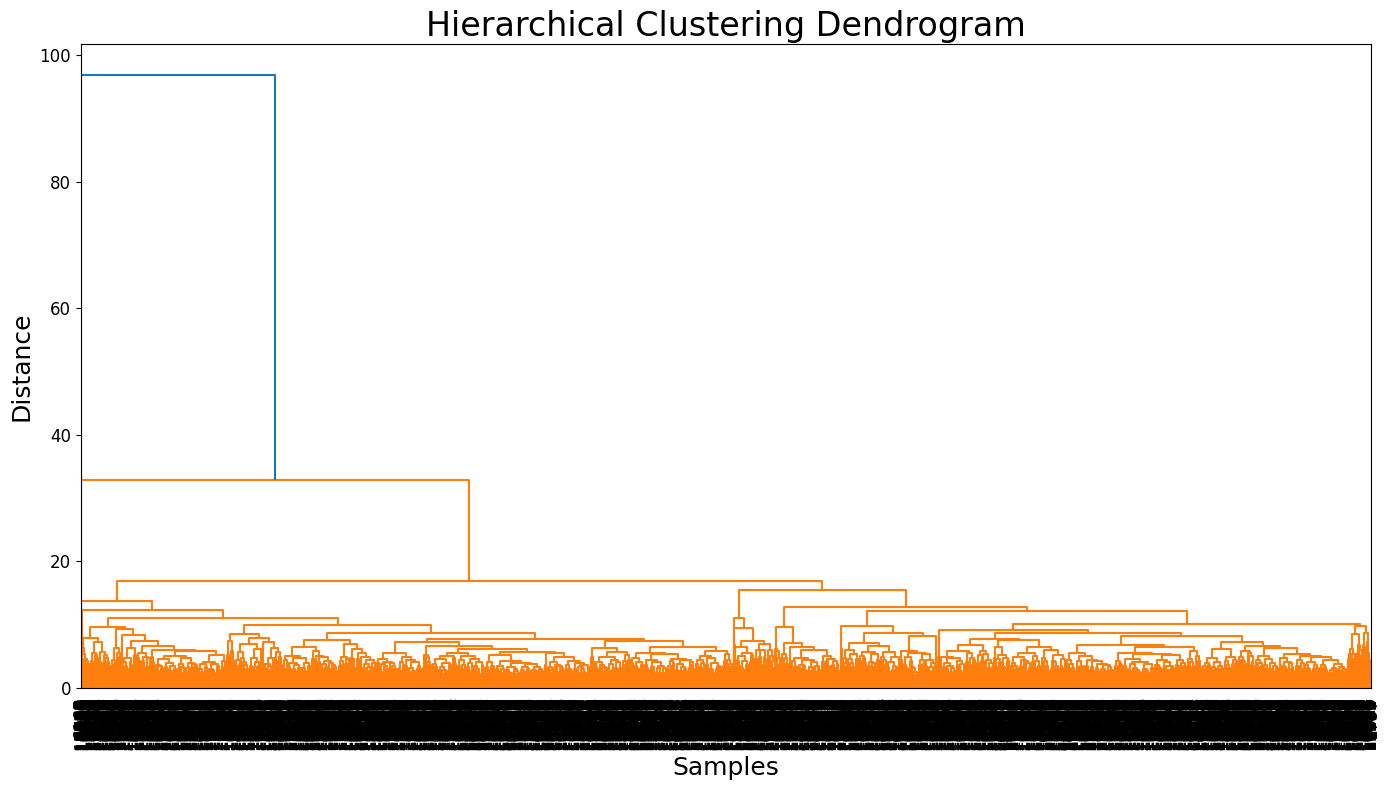

<Figure size 640x480 with 0 Axes>

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df.to_numpy())

linkage_data = linkage(df_scaled, method='complete', metric='euclidean')
# hierarchical clustering

# plot dendrogram
plt.figure(figsize=(14, 8))

dendrogram(linkage_data)

plt.title("Hierarchical Clustering Dendrogram", fontsize=24)
plt.xlabel("Samples", fontsize=18)
plt.ylabel("Distance", fontsize=18)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.savefig("dendrogram_scaled.png", dpi=300, bbox_inches="tight")
plt.show()
plt.clf()

In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import numpy as np
import pandas as pd
data = pl.read_csv("complete_aggregation3.csv")
df = data.select(pl.all().exclude("player"))
X = df.to_numpy()  # NO scaling

results = []
cluster_size_data = {}

for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    unique, counts = np.unique(labels, return_counts=True)
    cluster_counts = dict(zip(unique.tolist(), counts.tolist()))
    
    min_cluster_size = counts.min()
    n_singletons = np.sum(counts == 1)

    sil = silhouette_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    db = davies_bouldin_score(X, labels)

    print(f"\n=== k = {k} ===")
    print("Cluster sizes:", cluster_counts)
    print(f"Smallest cluster size: {min_cluster_size}")
    print(f"Singleton clusters: {n_singletons}")
    print(f"Silhouette: {sil:.4f}, CH: {ch:.2f}, DB: {db:.4f}")

    if n_singletons > 0:
        print("Warning: singleton clusters detected")
    elif min_cluster_size < 0.02 * len(X):
        print("Warning: very imbalanced clusters")

    results.append({
        "n_clusters": k,
        "silhouette_score": sil,
        "calinski_harabasz": ch,
        "davies_bouldin": db,
        "min_cluster_size": int(min_cluster_size),
        "singleton_clusters": int(n_singletons)
    })

    cluster_size_data[k] = cluster_counts

results_df = pd.DataFrame(results)
print("\nSummary:")
print(results_df)


=== k = 2 ===
Cluster sizes: {0: 13051, 1: 10928}
Smallest cluster size: 10928
Singleton clusters: 0
Silhouette: 0.3359, CH: 13851.83, DB: 1.0871

=== k = 3 ===
Cluster sizes: {0: 3643, 1: 10045, 2: 10291}
Smallest cluster size: 3643
Singleton clusters: 0
Silhouette: 0.3727, CH: 15356.55, DB: 0.9140

=== k = 4 ===
Cluster sizes: {0: 3118, 1: 10676, 2: 4774, 3: 5411}
Smallest cluster size: 3118
Singleton clusters: 0
Silhouette: 0.3288, CH: 15537.59, DB: 0.9314

=== k = 5 ===
Cluster sizes: {0: 4990, 1: 4379, 2: 4428, 3: 9163, 4: 1019}
Smallest cluster size: 1019
Singleton clusters: 0
Silhouette: 0.3252, CH: 14738.40, DB: 0.9314

Summary:
   n_clusters  silhouette_score  calinski_harabasz  davies_bouldin  \
0           2          0.335897       13851.825210        1.087132   
1           3          0.372733       15356.552628        0.914042   
2           4          0.328800       15537.591477        0.931359   
3           5          0.325152       14738.403317        0.931388   

   

In [8]:
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pl.read_csv("complete_aggregation3.csv")
df = data.select(pl.all().exclude("player"))
#scaler = StandardScaler()
#df = scaler.fit_transform(df.to_numpy())



linkage_data = linkage(df, method="complete")

results = []
cluster_size_data = {}

for k in range(2, 6):
    labels = fcluster(linkage_data, k, criterion="maxclust")

    unique, counts = np.unique(labels, return_counts=True)
    cluster_counts = dict(zip(unique.tolist(), counts.tolist()))
    min_cluster_size = counts.min()
    n_singletons = np.sum(counts == 1)
    smallest_pct = min_cluster_size / len(labels)

    sil = silhouette_score(df, labels)
    ch = calinski_harabasz_score(df, labels)
    db = davies_bouldin_score(df, labels)

    print(f"\n=== k = {k} ===")
    print("Cluster sizes:", cluster_counts)
    print(f"Smallest cluster size: {min_cluster_size}")
    print(f"Singleton clusters: {n_singletons}")
    print(f"Silhouette: {sil:.4f}, CH: {ch:.2f}, DB: {db:.4f}")

    if n_singletons > 0:
        print("Warning: clustering still contains singleton outlier clusters.")
    elif smallest_pct < 0.02:
        print("Warning: clustering is very imbalanced.")

    results.append({
        "n_clusters": k,
        "silhouette_score": sil,
        "calinski_harabasz": ch,
        "davies_bouldin": db,
        "min_cluster_size": int(min_cluster_size),
        "singleton_clusters": int(n_singletons)
    })

    cluster_size_data[k] = cluster_counts

results_df = pd.DataFrame(results)
print("\nSummary table:")
print(results_df)



=== k = 2 ===
Cluster sizes: {1: 279, 2: 23700}
Smallest cluster size: 279
Singleton clusters: 0
Silhouette: 0.4606, CH: 1419.66, DB: 0.6475

=== k = 3 ===
Cluster sizes: {1: 279, 2: 364, 3: 23336}
Smallest cluster size: 279
Singleton clusters: 0
Silhouette: 0.4483, CH: 2471.11, DB: 0.6085

=== k = 4 ===
Cluster sizes: {1: 278, 2: 1, 3: 364, 4: 23336}
Smallest cluster size: 1
Singleton clusters: 1
Silhouette: 0.4446, CH: 1660.44, DB: 0.4822

=== k = 5 ===
Cluster sizes: {1: 278, 2: 1, 3: 364, 4: 4593, 5: 18743}
Smallest cluster size: 1
Singleton clusters: 1
Silhouette: 0.2541, CH: 4405.51, DB: 0.6498

Summary table:
   n_clusters  silhouette_score  calinski_harabasz  davies_bouldin  \
0           2          0.460582        1419.664719        0.647499   
1           3          0.448321        2471.111285        0.608527   
2           4          0.444600        1660.437933        0.482181   
3           5          0.254074        4405.506875        0.649763   

   min_cluster_size  sin

In [50]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import numpy as np
import pandas as pd
data = pl.read_csv("complete_aggregation3.csv")
df = data.select(pl.all().exclude("player"))
X = df.to_numpy()  # NO scaling

results = []
cluster_size_data = {}

for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    unique, counts = np.unique(labels, return_counts=True)
    cluster_counts = dict(zip(unique.tolist(), counts.tolist()))
    
    min_cluster_size = counts.min()
    n_singletons = np.sum(counts == 1)

    sil = silhouette_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    db = davies_bouldin_score(X, labels)

    print(f"\n=== k = {k} ===")
    print("Cluster sizes:", cluster_counts)
    print(f"Smallest cluster size: {min_cluster_size}")
    print(f"Singleton clusters: {n_singletons}")
    print(f"Silhouette: {sil:.4f}, CH: {ch:.2f}, DB: {db:.4f}")

    if n_singletons > 0:
        print("Warning: singleton clusters detected")
    elif min_cluster_size < 0.02 * len(X):
        print("Warning: very imbalanced clusters")

    results.append({
        "n_clusters": k,
        "silhouette_score": sil,
        "calinski_harabasz": ch,
        "davies_bouldin": db,
        "min_cluster_size": int(min_cluster_size),
        "singleton_clusters": int(n_singletons)
    })

    cluster_size_data[k] = cluster_counts

results_df = pd.DataFrame(results)
print("\nSummary:")
print(results_df)


=== k = 2 ===
Cluster sizes: {0: 13051, 1: 10928}
Smallest cluster size: 10928
Singleton clusters: 0
Silhouette: 0.3359, CH: 13851.83, DB: 1.0871

=== k = 3 ===
Cluster sizes: {0: 3643, 1: 10045, 2: 10291}
Smallest cluster size: 3643
Singleton clusters: 0
Silhouette: 0.3727, CH: 15356.55, DB: 0.9140

=== k = 4 ===
Cluster sizes: {0: 3118, 1: 10676, 2: 4774, 3: 5411}
Smallest cluster size: 3118
Singleton clusters: 0
Silhouette: 0.3288, CH: 15537.59, DB: 0.9314

=== k = 5 ===
Cluster sizes: {0: 4990, 1: 4379, 2: 4428, 3: 9163, 4: 1019}
Smallest cluster size: 1019
Singleton clusters: 0
Silhouette: 0.3252, CH: 14738.40, DB: 0.9314

Summary:
   n_clusters  silhouette_score  calinski_harabasz  davies_bouldin  \
0           2          0.335897       13851.825210        1.087132   
1           3          0.372733       15356.552628        0.914042   
2           4          0.328800       15537.591477        0.931359   
3           5          0.325152       14738.403317        0.931388   

   

In [51]:
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import numpy as np
import pandas as pd
data = pl.read_csv("complete_aggregation3.csv")
df = data.select(pl.all().exclude("player"))
X = df.to_numpy()  # NO scaling

results = []
cluster_size_data = {}

for k in range(2, 6):
    spectral = SpectralClustering(
        n_clusters=k,
        affinity="nearest_neighbors",
        n_neighbors=10,
        assign_labels="kmeans",
        random_state=42
    )

    labels = spectral.fit_predict(X)

    unique, counts = np.unique(labels, return_counts=True)
    cluster_counts = dict(zip(unique.tolist(), counts.tolist()))

    min_cluster_size = counts.min()
    n_singletons = np.sum(counts == 1)

    sil = silhouette_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    db = davies_bouldin_score(X, labels)

    print(f"\n=== k = {k} ===")
    print("Cluster sizes:", cluster_counts)
    print(f"Smallest cluster size: {min_cluster_size}")
    print(f"Singleton clusters: {n_singletons}")
    print(f"Silhouette: {sil:.4f}, CH: {ch:.2f}, DB: {db:.4f}")

    if n_singletons > 0:
        print("Warning: singleton clusters detected")
    elif min_cluster_size < 0.02 * len(X):
        print("Warning: very imbalanced clusters")

    results.append({
        "n_clusters": k,
        "silhouette_score": sil,
        "calinski_harabasz": ch,
        "davies_bouldin": db,
        "min_cluster_size": int(min_cluster_size),
        "singleton_clusters": int(n_singletons)
    })

    cluster_size_data[k] = cluster_counts

results_df = pd.DataFrame(results)
print("\nSummary:")
print(results_df)


=== k = 2 ===
Cluster sizes: {0: 15958, 1: 8021}
Smallest cluster size: 8021
Singleton clusters: 0
Silhouette: 0.3269, CH: 13004.65, DB: 1.0123

=== k = 3 ===
Cluster sizes: {0: 8175, 1: 3791, 2: 12013}
Smallest cluster size: 3791
Singleton clusters: 0
Silhouette: 0.3637, CH: 14934.38, DB: 0.9400

=== k = 4 ===
Cluster sizes: {0: 3479, 1: 4725, 2: 2802, 3: 12973}
Smallest cluster size: 2802
Singleton clusters: 0
Silhouette: 0.3328, CH: 14402.84, DB: 0.8712

=== k = 5 ===
Cluster sizes: {0: 10549, 1: 6592, 2: 2792, 3: 2573, 4: 1473}
Smallest cluster size: 1473
Singleton clusters: 0
Silhouette: 0.2969, CH: 13411.97, DB: 0.9535

Summary:
   n_clusters  silhouette_score  calinski_harabasz  davies_bouldin  \
0           2          0.326885       13004.654810        1.012320   
1           3          0.363739       14934.381541        0.939980   
2           4          0.332839       14402.839054        0.871207   
3           5          0.296896       13411.971516        0.953475   

   mi